In [1]:
import pandas as pd
test = pd.read_csv("test.csv")
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [2]:
train = pd.read_csv("train.csv")
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Data Loading

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
train.describe(include="all")

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


In [5]:
missing_values = train.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [6]:
less = missing_values[missing_values < 1000].index
over = missing_values[missing_values >= 1000].index

In [7]:
numeric_features = train[less].select_dtypes(include=['number']).columns
train[numeric_features] = train[numeric_features].fillna(train[numeric_features].median())

In [8]:
kategorical_features = train[less].select_dtypes(include=['object']).columns

for column in kategorical_features:
      train[column] = train[column].fillna(train[column].mode()[0])

In [9]:
df = train.drop(columns=over)

In [10]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

Mengatasi Missing Value

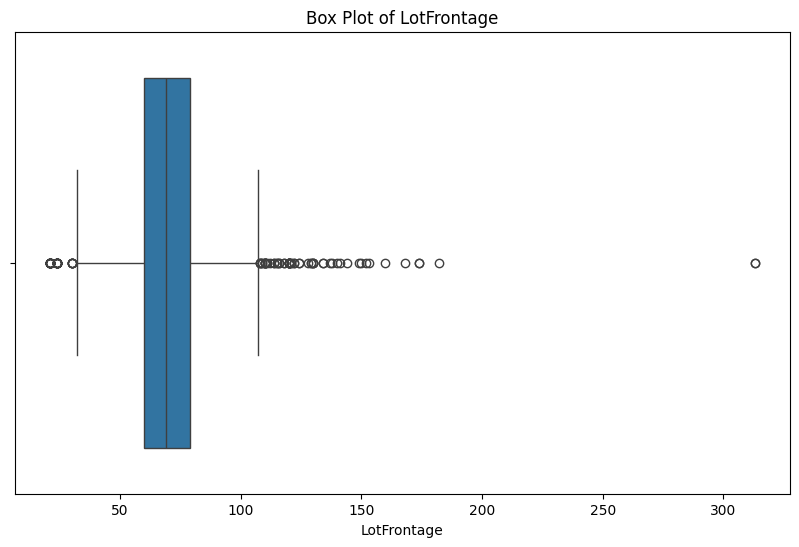

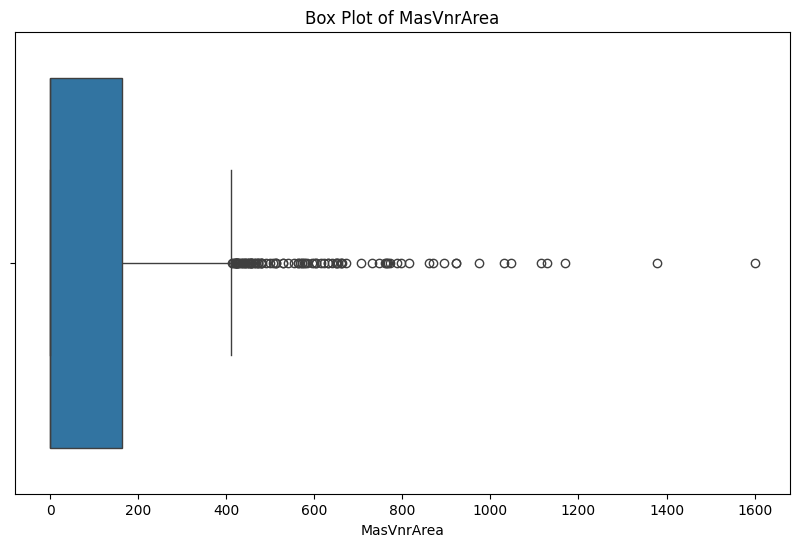

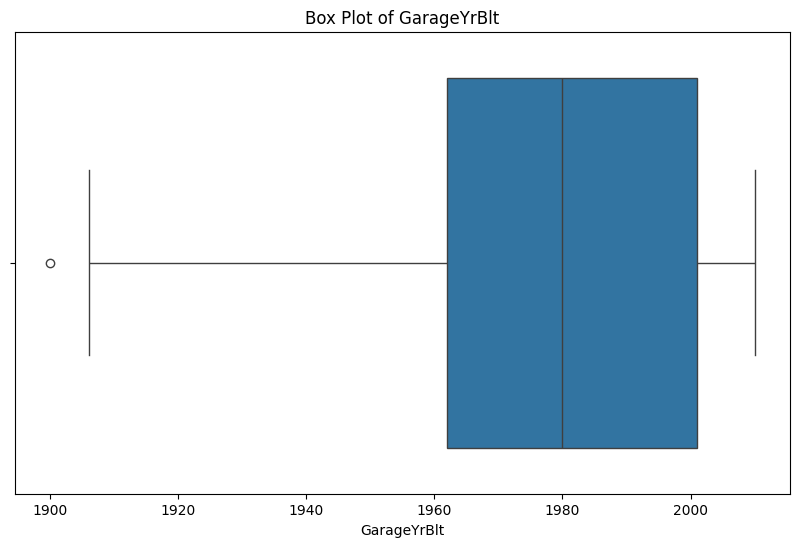

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

for feature in numeric_features:
   plt.figure(figsize=(10, 6))
   sns.boxplot(x=df[feature])
   plt.title(f'Box Plot of {feature}')
   plt.show()

setelah di baca di situ banyak titik titik yang tidak dekat dengan box plot dan itu adalah outliernya

In [12]:
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1

In [13]:
# Filter dataframe untuk hanya menyimpan baris yang tidak mengandung outliers pada kolom numerik
condition = ~((df[numeric_features] < (Q1 - 1.5 * IQR)) | (df[numeric_features] > (Q3 + 1.5 * IQR))).any(axis=1)
df_filtered_numeric = df.loc[condition, numeric_features]

# Menggabungkan kembali dengan kolom kategorikal
categorical_features = df.select_dtypes(include=['object']).columns
df = pd.concat([df_filtered_numeric, df.loc[condition, categorical_features]], axis=1)

Mengatasi Outlier 

In [14]:
from sklearn.preprocessing import StandardScaler

# Standardisasi fitur numerik
scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

In [15]:
print(numeric_features)
print(len(numeric_features))


Index(['LotFrontage', 'MasVnrArea', 'GarageYrBlt'], dtype='object')
3


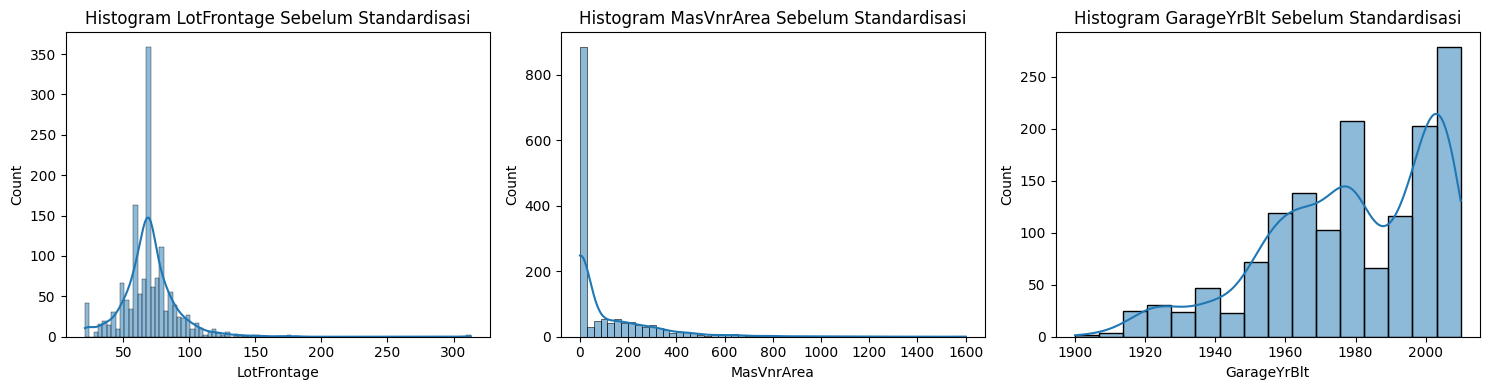

In [17]:
plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_features):
    plt.subplot(1, 3, i+1)
    sns.histplot(train[col], kde=True)
    plt.title(f"Histogram {col} Sebelum Standardisasi")
plt.tight_layout()
plt.show()


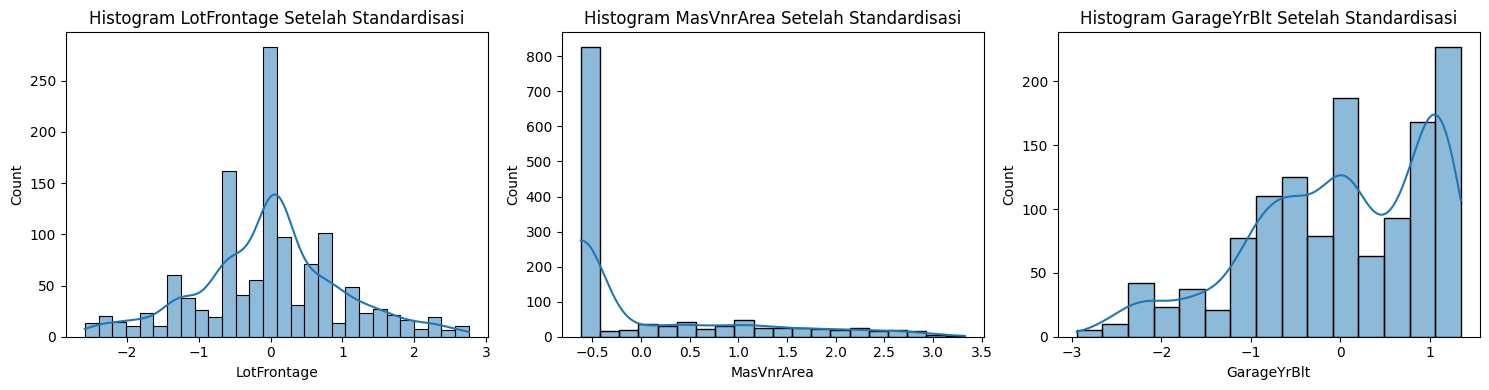

In [18]:
plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_features):
   plt.subplot(1, 3, i+1)
   sns.histplot(df[col], kde=True)
   plt.title(f"Histogram {col} Setelah Standardisasi")
plt.tight_layout()
plt.show()


In [19]:
# Mengidentifikasi baris duplikat
duplicates = df.duplicated()
 
print("Baris duplikat:")
print(df[duplicates])

Baris duplikat:
      LotFrontage  MasVnrArea  GarageYrBlt MSZoning Street LotShape  \
971     -2.297189    0.401061     1.057175       RL   Pave      Reg   
1368     0.052259    1.016993     1.057175       RM   Pave      Reg   

     LandContour Utilities LotConfig LandSlope  ... KitchenQual Functional  \
971          Lvl    AllPub    Inside       Gtl  ...          Gd        Typ   
1368         Lvl    AllPub    Inside       Gtl  ...          Gd        Typ   

     FireplaceQu GarageType GarageFinish GarageQual GarageCond PavedDrive  \
971           Gd    BuiltIn          RFn         TA         TA          Y   
1368          Gd     Attchd          Fin         TA         TA          Y   

     SaleType SaleCondition  
971        WD        Normal  
1368       WD        Normal  

[2 rows x 42 columns]


In [20]:
# Menghapus baris duplikat
df = df.drop_duplicates()
 
print("DataFrame setelah menghapus duplikat:")
print(df)

DataFrame setelah menghapus duplikat:
      LotFrontage  MasVnrArea  GarageYrBlt MSZoning Street LotShape  \
0       -0.232523    1.267216     1.057175       RL   Pave      Reg   
1        0.835408   -0.619077    -0.056825       RL   Pave      Reg   
2       -0.018937    0.940002     0.974656       RL   Pave      IR1   
3       -0.588500   -0.619077     0.850879       RL   Pave      IR1   
4        1.120189    2.749303     0.933397       RL   Pave      IR1   
...           ...         ...          ...      ...    ...      ...   
1455    -0.446109   -0.619077     0.892138       RL   Pave      Reg   
1456     1.191385    0.526172     0.025693       RL   Pave      Reg   
1457    -0.161328   -0.619077    -1.500899       RL   Pave      Reg   
1458    -0.018937   -0.619077    -1.129566       RL   Pave      Reg   
1459     0.479431   -0.619077    -0.510677       RL   Pave      Reg   

     LandContour Utilities LotConfig LandSlope  ... KitchenQual Functional  \
0            Lvl    AllPub    I

In [21]:
category_features = df.select_dtypes(include=['object']).columns
df[category_features]

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal
1,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
1456,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,...,TA,Min1,TA,Attchd,Unf,TA,TA,Y,WD,Normal
1457,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal
1458,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,...,Gd,Typ,Gd,Attchd,Unf,TA,TA,Y,WD,Normal


In [22]:
df_one_hot = pd.get_dummies(df, columns=category_features)
df_one_hot

,LotFrontage,MasVnrArea,GarageYrBlt,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-0.232523,1.267216,1.057175,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,False
1,0.835408,-0.619077,-0.056825,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,False
2,-0.018937,0.940002,0.974656,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,False
3,-0.588500,-0.619077,0.850879,False,False,False,True,False,False,True,...,False,False,False,True,True,False,False,False,False,False
4,1.120189,2.749303,0.933397,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,-0.446109,-0.619077,0.892138,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,False
1456,1.191385,0.526172,0.025693,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,False
1457,-0.161328,-0.619077,-1.500899,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,False
1458,-0.018937,-0.619077,-1.129566,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,False


In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_lencoder = pd.DataFrame(df)

for col in category_features:
    df_lencoder[col] = label_encoder.fit_transform(df[col])

df_lencoder

,LotFrontage,MasVnrArea,GarageYrBlt,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,-0.232523,1.267216,1.057175,3,1,3,3,0,4,0,...,2,6,2,1,1,4,4,2,8,4
1,0.835408,-0.619077,-0.056825,3,1,3,3,0,2,0,...,3,6,4,1,1,4,4,2,8,4
2,-0.018937,0.940002,0.974656,3,1,0,3,0,4,0,...,2,6,4,1,1,4,4,2,8,4
3,-0.588500,-0.619077,0.850879,3,1,0,3,0,0,0,...,2,6,2,5,2,4,4,2,8,0
4,1.120189,2.749303,0.933397,3,1,0,3,0,2,0,...,2,6,4,1,1,4,4,2,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,-0.446109,-0.619077,0.892138,3,1,3,3,0,4,0,...,3,6,4,1,1,4,4,2,8,4
1456,1.191385,0.526172,0.025693,3,1,3,3,0,4,0,...,3,2,4,1,2,4,4,2,8,4
1457,-0.161328,-0.619077,-1.500899,3,1,3,3,0,4,0,...,2,6,2,1,1,4,4,2,8,4
1458,-0.018937,-0.619077,-1.129566,3,1,3,3,0,4,0,...,2,6,2,1,2,4,4,2,8,4


In [24]:
df_lencoder.head()

,LotFrontage,MasVnrArea,GarageYrBlt,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,-0.232523,1.267216,1.057175,3,1,3,3,0,4,0,...,2,6,2,1,1,4,4,2,8,4
1,0.835408,-0.619077,-0.056825,3,1,3,3,0,2,0,...,3,6,4,1,1,4,4,2,8,4
2,-0.018937,0.940002,0.974656,3,1,0,3,0,4,0,...,2,6,4,1,1,4,4,2,8,4
3,-0.588500,-0.619077,0.850879,3,1,0,3,0,0,0,...,2,6,2,5,2,4,4,2,8,0
4,1.120189,2.749303,0.933397,3,1,0,3,0,2,0,...,2,6,4,1,1,4,4,2,8,4
